In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import AffinityPropagation
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score,
    euclidean_distances,
)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 2.Clusstering Affinity Propagation Algorithtms

In [3]:
df = df.drop(columns='CustomerID')

In [4]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas") # Tambahkan baris ini sebelum fit_transform
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


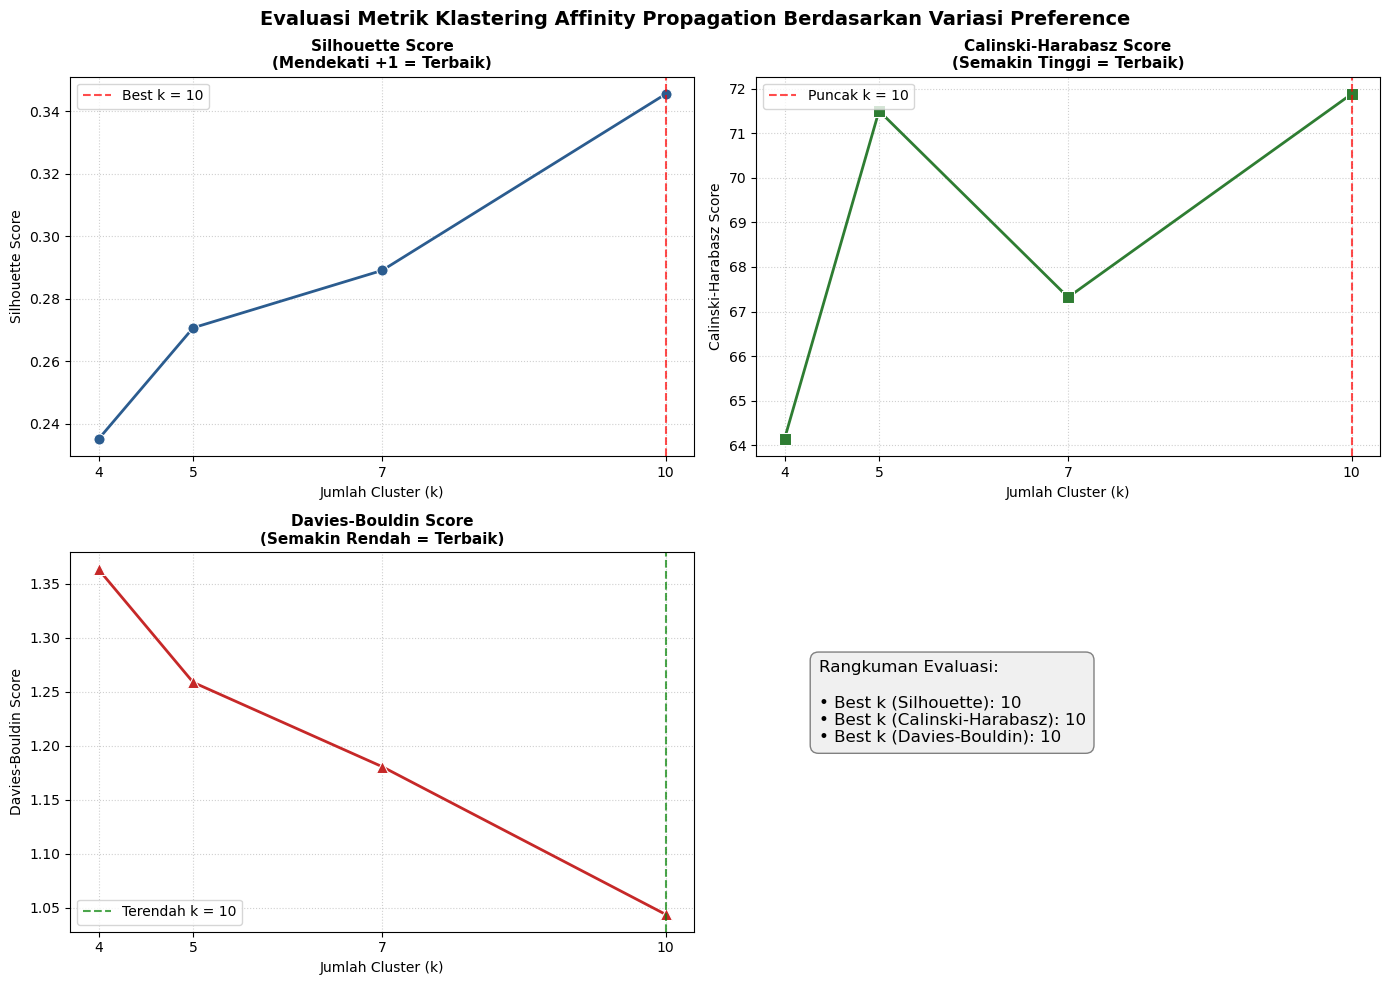

,n_clusters(k),preference,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,4,-76.25,0.235196,64.142513,1.363147
1,5,-57.50,0.270759,71.499731,1.258610
2,7,-38.75,0.289121,67.319205,1.180501
3,10,-20.00,0.345548,71.877422,1.043618


In [5]:
preference_range = np.linspace(-20.0,-95.0, 5)

result = []
sil_scores = []
ch_scores = []
db_scores = []
pref_num = []
nclusters = []

for pref in preference_range:
    model_ap = AffinityPropagation(preference=pref,random_state=42).fit(X_cleaned)
    labels = model_ap.labels_
    #hitung jumlah klaster unik
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if 1 < n_clusters < len(X_cleaned):
        sil_scores.append(silhouette_score(X_cleaned,labels))
        ch_scores.append(calinski_harabasz_score(X_cleaned,labels))
        db_scores.append(davies_bouldin_score(X_cleaned,labels))
        pref_num.append(pref)
        nclusters.append(n_clusters)

df_scores = pd.DataFrame({
    'n_clusters(k)': nclusters,
    'preference': pref_num,
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})
# Hapus duplikat k jika ada beberapa preference menghasilkan k yang sama
df_scores = df_scores.drop_duplicates(subset=['n_clusters(k)']).sort_values('n_clusters(k)').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_ticks = df_scores['n_clusters(k)'].values

# --- Subplot 1: Silhouette Score (axes[0, 0]) ---
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 0], x='n_clusters(k)', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 0].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 0].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(k_ticks)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# --- Subplot 2: Calinski-Harabasz Score (axes[0, 1]) ---
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 1], x='n_clusters(k)', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[0, 1].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[0, 1].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(k_ticks)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# --- Subplot 3: Davies-Bouldin Score (axes[1, 0]) ---
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 0], x='n_clusters(k)', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 0].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 0].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(k_ticks)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# --- Subplot 4: Kosongkan atau bisa diisi informasi summary ---
axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.5, f"Rangkuman Evaluasi:\n\n• Best k (Silhouette): {best_k_sil}\n• Best k (Calinski-Harabasz): {best_k_ch}\n• Best k (Davies-Bouldin): {best_k_db}", 
                fontsize=12, bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", edgecolor="gray"))

plt.suptitle('Evaluasi Metrik Klastering Affinity Propagation Berdasarkan Variasi Preference', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
df_scores

In [6]:
pref = -76.25
best_ap = AffinityPropagation(preference=pref,random_state=42)
df['Cluster'] = best_ap.fit_predict(X_cleaned)
n_clusters = len(best_ap.cluster_centers_indices_)

if n_clusters == 0:
    print("⚠️ Peringatan: Model tidak konvergen! Coba naikkan parameter 'damping' (misal: damping=0.8).")
else:
    print(f"✅ Model Berhasil Konvergen!")
    print(f"Jumlah klaster yang terbentuk: {n_clusters}")
    print(f"Indeks data yang menjadi Exemplar/Pusat: {best_ap.cluster_centers_indices_}")

df.head()

✅ Model Berhasil Konvergen!
Jumlah klaster yang terbentuk: 4
Indeks data yang menjadi Exemplar/Pusat: [ 43  74 137 148]


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,0
1,Male,21,15,81,0
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0


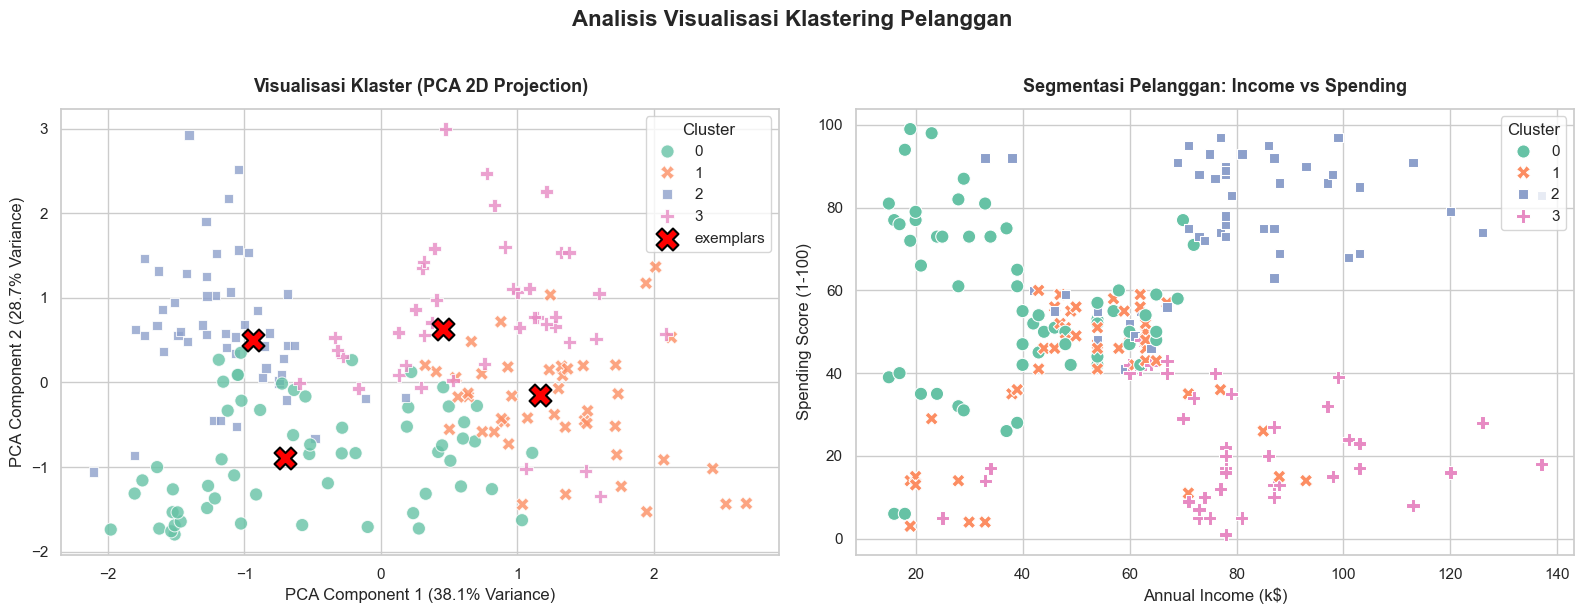

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cleaned)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster']

exemplars_df = pd.DataFrame(best_ap.cluster_centers_, columns=X_cleaned.columns)
exemplars_pca = pca.transform(exemplars_df)

sns.set_theme(style="whitegrid")
palette = 'Set2'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0],x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
axes[0].scatter(exemplars_pca[:, 0], exemplars_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='exemplars') # Plot Centroid
axes[0].set_title('Visualisasi Klaster (PCA 2D Projection)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[0].legend(title='Cluster', loc='upper right')

sns.scatterplot( ax=axes[1],x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,  palette=palette, s=90, style='Cluster')
axes[1].set_title('Segmentasi Pelanggan: Income vs Spending', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(title='Cluster', loc='upper right')

plt.suptitle('Analisis Visualisasi Klastering Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

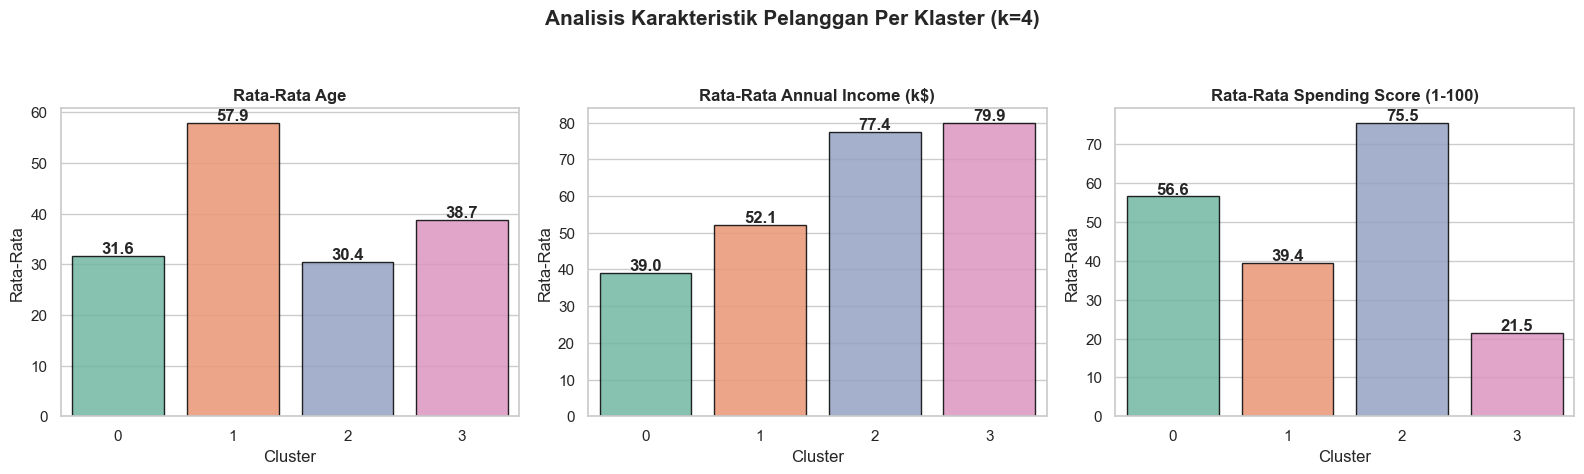

In [8]:
df_profile = df.groupby('Cluster')[num_cols].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(num_cols):
    sns.barplot(ax=axes[i], x='Cluster', y=col, data=df_profile,hue='Cluster',legend=False,palette=palette, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Rata-Rata {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Rata-Rata')
    for p in axes[i].patches: # Menambahkan label nilai angka di atas bar
        axes[i].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle(f'Analisis Karakteristik Pelanggan Per Klaster (k={n_clusters})', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()